In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
X, y = make_moons(n_samples=500, noise=0.2, random_state=42)

y = y.reshape(-1,1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [3]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

def sigmoid_derivative(x):
    return x*(1-x)

In [4]:
input_size = 2
hidden_size = 5
output_size = 1

np.random.seed(42)

W1 = np.random.randn(input_size, hidden_size)
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size)
b2 = np.zeros((1, output_size))

In [5]:
learning_rate = 0.01
epochs = 5000

losses = []

for epoch in range(epochs):

    # Forward propagation
    z1 = np.dot(X_train, W1) + b1
    a1 = sigmoid(z1)

    z2 = np.dot(a1, W2) + b2
    y_pred = sigmoid(z2)

    # Loss (Binary Cross Entropy)
    loss = -np.mean(y_train*np.log(y_pred+1e-8) +
                    (1-y_train)*np.log(1-y_pred+1e-8))

    losses.append(loss)

    # Backpropagation
    dz2 = y_pred - y_train
    dW2 = np.dot(a1.T, dz2)
    db2 = np.sum(dz2, axis=0, keepdims=True)

    dz1 = np.dot(dz2, W2.T) * sigmoid_derivative(a1)
    dW1 = np.dot(X_train.T, dz1)
    db1 = np.sum(dz1, axis=0, keepdims=True)

    # Update weights
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    if epoch % 500 == 0:
        print("Epoch:", epoch, "Loss:", loss)

Epoch: 0 Loss: 1.232748135682654
Epoch: 500 Loss: 0.075468298497555
Epoch: 1000 Loss: 0.056708557802498484
Epoch: 1500 Loss: 0.04974320525738227
Epoch: 2000 Loss: 0.04277954476087152
Epoch: 2500 Loss: 0.03838704601358999
Epoch: 3000 Loss: 0.03593658795511611
Epoch: 3500 Loss: 0.03423126136584326
Epoch: 4000 Loss: 0.032805764920414225
Epoch: 4500 Loss: 0.03150354615404884


In [6]:
def predict(X):
    
    z1 = np.dot(X, W1) + b1
    a1 = sigmoid(z1)

    z2 = np.dot(a1, W2) + b2
    y_pred = sigmoid(z2)

    return (y_pred > 0.5).astype(int)

In [7]:
y_test_pred = predict(X_test)

accuracy = np.mean(y_test_pred == y_test)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.97


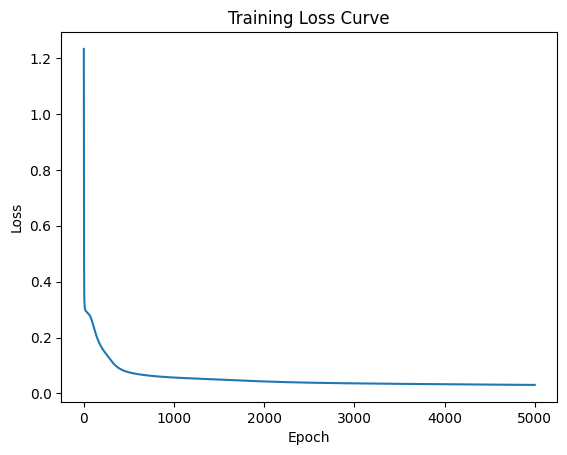

In [8]:
plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")

plt.show()

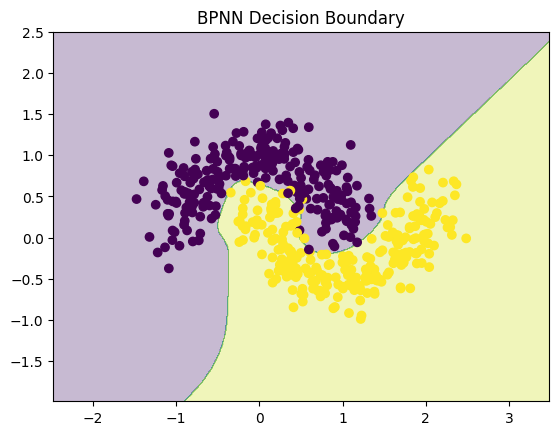

In [9]:
def plot_decision_boundary():
    
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.01),
        np.arange(y_min, y_max, 0.01)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    grid = scaler.transform(grid)

    preds = predict(grid)
    preds = preds.reshape(xx.shape)

    plt.contourf(xx, yy, preds, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y.ravel())

    plt.title("BPNN Decision Boundary")
    plt.show()

plot_decision_boundary()

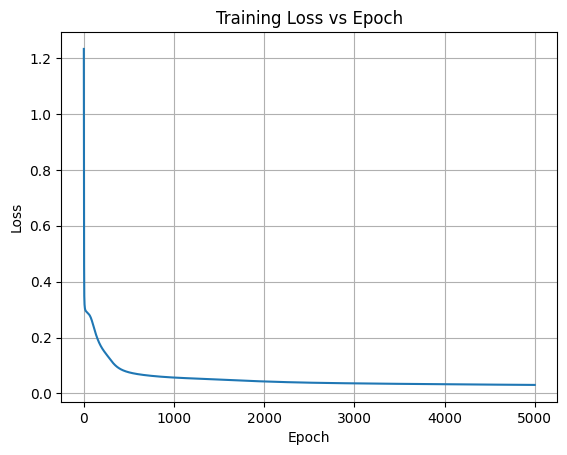

In [10]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(range(len(losses)), losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Epoch")

plt.grid(True)

plt.show()